# Synthetic photometry from the final GP

This notebook writes **synthetic AB photometry** of the final 2D-GP SED surface through every filter that has data in the input photometry file. It's meant for an external $\chi^2$ comparison against the input data. It **only produces the files**; the comparison itself is left to the analysis code.

**Input surface:** `Outputs/<SN>/FINAL_spectra_2dim/as_observed/{log10_phase}_FINAL_spec*.txt` (linear Å, linear $F_\lambda$, $\sigma_{F_\lambda}$). Each file stem is $\log_{10}(\mathrm{MJD}-t_0)$ in days, with $t_0$ = `pipeline_config.SN_EXPLOSION_MJD[SN]`.

**Input photometry:** `Inputs/Photometry/1_LCs_flux_raw/<SN>.dat` (catalog AB mags, *not* dust-corrected). This sets which bands are synthesized and the epochs for output file 2.

## Toggles

| Knob | Options | Meaning |
|---|---|---|
| `SYNTH_METHOD` | `"true_ab"` (**recommended**) | Photon-counting AB: $m=-2.5\log_{10}\frac{\int F_\lambda T\lambda\,d\lambda}{\int F^{AB}_\lambda T\lambda\,d\lambda}$. Same as synphot `effstim('abmag')` and the λ-weighted band mean the mangling step uses. |
| | `"wtf_band_ab"` | `what_the_flux.Band_AB` convention: $m=-2.5\log_{10}\frac{\int F_\lambda T\,d\lambda}{\int F^{AB}_\lambda T\,d\lambda}$. This is the inverse of how notebook 1 turned catalog mags into `Flux`. |
| `APPLY_EXTINCTION` | `True` | Writes **both** `mag_AB_obs` (dust put back; compare to the raw `Mag` column) and `mag_AB_dustcorr` (spectra as-is), plus `A_ext_band`. |
| | `False` | Writes only `mag_AB_model`: the FINAL spectra as-is, no extinction applied. |

The FINAL spectra are **dust-corrected**: the GP was trained on the notebook-1 dust-corrected fluxes. `mag_AB_obs` undoes notebook 1 **exactly**. For each band it adds $A_{\rm band}=-2.5\log_{10}(\mathrm{ext}_{\rm host}\,\mathrm{ext}_{\rm MW})$, using the same CCM89 band-averaged factors, $E(B-V)$ from `info.dat`, and $R_V$ that notebook 1 divided out.

## Other conventions
- **Coverage:** a band gets NaN mags unless ≥ `MIN_COVERAGE` of its (method-weighted) throughput lies inside the spectrum range (≈3290–24500 Å). `coverage_frac` records the fraction.
- **Errors:** `*_err` propagates the FINAL `fluxerr`, assuming errors are **fully correlated across wavelength within a band** (conservative for a GP surface). These are *model* errors; the data errors are in the input file.
- **Integration:** trapezoid rule on the union of the filter and spectrum wavelength grids, with the spectrum linearly interpolated. Checked against brute-force fine-grid integration (<1e-4 mag), synphot (~1e-3 mag where the filter is well sampled), and `what_the_flux.Band_AB` (<1e-4 mag).
- `excluded_from_fit` = band is in `filter_plot_config.json` `exclude_filt`, so it was not used to build the GP. Those bands are still synthesized.

## Outputs (`Outputs/<SN>/synthetic_photometry/`)
1. `*_grid.csv`: the synthetic light curve in each band, one row per band × FINAL-spectrum epoch.
2. `*_at_data.csv`: file 1 interpolated (linear in $\log_{10}$ phase and in mag) to **every row of the input photometry file**. `input_row` is the 0-based row index of that file. Rows outside the synthetic phase range, or in bands that could not be synthesized, are NaN.
3. `*_meta.json`: the settings used.

## Magnitude ↔ flux conventions (read before using these files)

**Use `SYNTH_METHOD = "true_ab"`.** The input photometry is reported in AB mags in each instrument's own (natural) filter system. The filter files in `Inputs/Filters/GeneralFilters` are those instruments' **photon-counting** throughputs: filter × QE × optics.

### AB is defined for photon-counting detectors
$$m_{AB} = -2.5\log_{10}\frac{\int f_\nu\,S\,d\nu/\nu}{\int 3631\,\mathrm{Jy}\,S\,d\nu/\nu}
= -2.5\log_{10}\frac{\int f_\lambda\,S\,\lambda\,d\lambda}{\int f^{AB}_\lambda\,S\,\lambda\,d\lambda},
\qquad f^{AB}_\lambda = 3631\,\mathrm{Jy}\,\frac{c}{\lambda^2}$$
The factor of $\lambda$ comes from counting photons: the number of photons per unit energy is $\propto\lambda$. This is the convention of Fukugita+96, Tokunaga & Vacca 2005, Bessell & Murphy 2012, SVO, synphot and sncosmo, and survey zeropoints are tied to it. **That is `true_ab`.**

`wtf_band_ab` drops the $\lambda$ (energy-counting weighting). That is only correct if a filter curve is an *energy* response, as in some classic tables such as Bessell UBVRI, where $S_{\rm photon}=T_{\rm energy}/\lambda$. For flat-$f_\nu$ sources the two agree. For the kilonova SEDs they differ by ~0.01–0.05 mag, more in wide filters. The toggle is kept only for comparison with `what_the_flux`.

### Converting a magnitude to a flux: use the pivot wavelength
A magnitude is band-integrated. The natural "band flux" for a photon-counting band is the photon-weighted mean
$$\langle f_\lambda\rangle = \frac{\int f_\lambda S\lambda\,d\lambda}{\int S\lambda\,d\lambda}.$$
For AB magnitudes the following identity is **exact and independent of the SED**:
$$\langle f_\lambda\rangle = 10^{-0.4(m_{AB}+48.60)}\,\frac{c}{\lambda_{\rm piv}^2},\qquad
\lambda_{\rm piv}=\sqrt{\frac{\int S\lambda\,d\lambda}{\int S/\lambda\,d\lambda}}.$$
- The pipeline's mangling step fits exactly this quantity, $\int\lambda T F\,d\lambda/\int\lambda T\,d\lambda$. So the input fluxes should be `Flux = 10**(-0.4*(Mag+48.6)) * c / lambda_piv**2` and `Flux_err = Flux * 0.4*ln(10) * Mag_err`. The linear error propagation is fine for S/N ≳ 10.
- With that convention, comparing **synthetic `true_ab` mags against `Mag`** and comparing **$\langle f_\lambda\rangle_{\rm synth}$ against `Flux`** give identical residuals. The $\chi^2$ can be done in either space; flux space handles low-S/N points more symmetrically.
- The *effective* wavelength, $\lambda_{\rm eff}=\int\lambda f_\lambda S\lambda\,d\lambda/\int f_\lambda S\lambda\,d\lambda$, depends on the SED, so it moves as the kilonova cools. It only matters when you need to place a flux at a single wavelength, e.g. when plotting an SED. It is never needed for band-integrated comparisons like these.

### ⚠️ Known issue with the current AT2017gfo input fluxes (as of 2026-10)
The `Flux` column of `1_LCs_flux_raw/AT2017gfo.dat` was produced as $F_\nu c/\lambda^2$ at a wavelength from a buggy "effective wavelength" function: a double cumulative sum puts $\lambda$ on the blue edge of each filter. As a result, `Flux` is too bright by $5\log_{10}(\lambda_{\rm piv}/\lambda_{\rm used})\approx$ 0.07–0.6 mag, depending on the band. The GP reproduces those fluxes, so **until the input fluxes are regenerated with $\lambda_{\rm piv}$ and the pipeline is rerun, the synthetic mags here will be systematically brighter than the catalog `Mag` column** (median ≈ 0.19 mag). This is not a problem with the GP or with this notebook.

### Caveats for later
- **Extinction:** `mag_AB_obs` adds back the same band-averaged CCM89 factor notebook 1 removed: flat-spectrum average, energy weighting. That keeps it an exact inverse of what was done to the data. A fully self-consistent treatment would redden the SED itself and then synthesize, which changes $A_{\rm band}$ by ≲0.01 mag here.
- **Transformed photometry:** these filter curves are correct for **natural-system** mags. If a paper reports mags *transformed to a standard system* (e.g. SDSS/PS1 via color terms), use the standard system's response instead. Otherwise you get S-correction–sized errors, which can reach ~0.05–0.1 mag for kilonova colors.

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pipeline_config as pconf

pconf.ensure_helper_paths()
import synthetic_photometry_export as sp
from comparison_check_log_utils import t0_fix_from_late_lc
from comparison_trapz_lc import resolve_filter_path

In [2]:
# ===================== configuration =====================
SNNAME = pconf.SNNAME_DEFAULT
COCO_PATH = pconf.COCO_PATH

SYNTH_METHOD = "true_ab"      # "true_ab" | "wtf_band_ab"
APPLY_EXTINCTION = True       # True: mag_AB_obs + mag_AB_dustcorr ; False: mag_AB_model (as-is)
MIN_COVERAGE = 0.99           # min fraction of filter throughput inside the spectrum
RV_MW = 3.1                   # NB1: MW uses CCM89 default R_V = 3.1
RV_HOST = 3.1                 # NB1: RV_dict[Type] (KN -> 3.1)
BANDS = None                  # None -> every band in the raw photometry file; or e.g. ["Swope_g"]

RAW_PHOTOMETRY_PATH = os.path.join(COCO_PATH, "Inputs", "Photometry", "1_LCs_flux_raw", "%s.dat" % SNNAME)
INFO_PATH = os.path.join(COCO_PATH, "Inputs", "SNe_Info", "info.dat")
FILTERS_PARENT = os.path.join(COCO_PATH, "Inputs", "Filters")
FINAL_DIR = pconf.final_spectra_qa_dir(pconf.outputs_root(COCO_PATH), SNNAME, variant="as_observed")
OUT_DIR = os.path.join(pconf.outputs_root(COCO_PATH), SNNAME, "synthetic_photometry")
# ==========================================================

assert SYNTH_METHOD in sp.SYNTH_METHODS, SYNTH_METHOD
print("FINAL spectra :", FINAL_DIR, "(%d files)" % len(sp.list_final_spectra(FINAL_DIR)))
print("Raw photometry:", RAW_PHOTOMETRY_PATH)
print("Output dir    :", OUT_DIR)

FINAL spectra : /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/FINAL_spectra_2dim/as_observed (245 files)
Raw photometry: /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat
Output dir    : /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/synthetic_photometry


### Phase zero, dust parameters, and filters

In [3]:
T0_MJD = pconf.explosion_date_mjd(SNNAME)
_t0_lc = t0_fix_from_late_lc(os.path.join(COCO_PATH, "Inputs", "Photometry", "3_LCs_extrapolated"), SNNAME)
if abs(_t0_lc - T0_MJD) > 1e-4:
    warnings.warn("SN_EXPLOSION_MJD (%.6f) != MJD-Phase of 3_LCs_extrapolated (%.6f); "
                  "check which t0 the FINAL spectra were built with." % (T0_MJD, _t0_lc))
print("t0 (MJD) = %.8f" % T0_MJD)

info = sp.load_sn_info(INFO_PATH, SNNAME)
EXT_KWARGS = dict(ebv_mw=info["EBV_MW"], rv_mw=RV_MW, ebv_host=info["EBV_host"],
                  rv_host=RV_HOST, redshift=info["z"])
print("dust:", EXT_KWARGS if APPLY_EXTINCTION else "(not applied)")

raw = pd.read_csv(RAW_PHOTOMETRY_PATH)
bands_req = sorted(raw["band"].dropna().astype(str).unique()) if BANDS is None else list(BANDS)

filter_paths, missing = {}, []
for b in bands_req:
    try:
        filter_paths[b] = resolve_filter_path(b, filters_parent=FILTERS_PARENT, snname=SNNAME)
    except FileNotFoundError:
        missing.append(b)
bands = [b for b in bands_req if b in filter_paths]
print("%d bands with filter curves" % len(bands))
if missing:
    warnings.warn("No filter curve for %s; these bands are skipped." % missing)

t0 (MJD) = 57982.52851852
dust: {'ebv_mw': 0.1053, 'rv_mw': 3.1, 'ebv_host': 0.0, 'rv_host': 3.1, 'redshift': 0.00984}
69 bands with filter curves


### 1) Synthetic light curves on the FINAL-spectrum epochs

In [4]:
grid = sp.synth_lightcurves_on_grid(
    FINAL_DIR, bands, filter_paths,
    t0_mjd=T0_MJD, method=SYNTH_METHOD,
    apply_extinction=APPLY_EXTINCTION, ext_kwargs=EXT_KWARGS,
    min_coverage=MIN_COVERAGE, excluded_bands=pconf.excluded_bands(),
)
MAG_COLS = [c for c in grid.columns if c.startswith("mag_AB_")]
grid.head()

,band,MJD,phase_days,log10_phase,spec_file,coverage_frac,excluded_from_fit,mag_AB_obs,mag_AB_obs_err,mag_AB_dustcorr,mag_AB_dustcorr_err,A_ext_band
0,ANDICAM_K,57982.529619,0.001100,-2.958607,-2.958607_FINAL_spec_FL.txt,1.0,False,25.356544,2.414149,25.317752,2.414149,0.038792
1,ANDICAM_K,57982.530475,0.001956,-2.708607,-2.708607_FINAL_spec_FL.txt,1.0,False,24.677372,2.094303,24.638580,2.094303,0.038792
2,ANDICAM_K,57982.531997,0.003479,-2.458607,-2.458607_FINAL_spec_FL.txt,1.0,False,24.004527,1.688979,23.965735,1.688979,0.038792
3,ANDICAM_K,57982.534704,0.006186,-2.208607,-2.208607_FINAL_spec_FL.txt,1.0,False,23.342028,1.207326,23.303236,1.207326,0.038792
4,ANDICAM_K,57982.539519,0.011000,-1.958607,-1.958607_FINAL_spec_FL.txt,1.0,False,22.691227,0.733845,22.652435,0.733845,0.038792


### 2) Interpolated to every input-photometry row

In [5]:
at_data = sp.interpolate_to_observations(grid, raw, t0_mjd=T0_MJD)
at_data.head()

,input_row,MJD,band,phase_days,log10_phase,mag_AB_obs,mag_AB_obs_err,mag_AB_dustcorr,mag_AB_dustcorr_err,coverage_frac,excluded_from_fit,nearest_gp_epoch_dt_days
0,0,57982.981,Swope_i,0.452481,-0.344399,17.113632,0.168316,16.901359,0.168316,1.0,False,0.060476
1,1,57982.990,FourStar_H,0.461481,-0.335846,18.123978,0.181065,18.062926,0.181065,1.0,False,0.069476
2,2,57982.999,VISTA_Ks,0.470481,-0.327457,18.473542,0.179064,18.435066,0.179064,1.0,False,0.078476
3,3,57983.000,FourStar_J,0.471481,-0.326535,17.913584,0.159286,17.819960,0.159286,1.0,False,0.079476
4,4,57983.003,DECam_i,0.474481,-0.323781,17.116673,0.163791,16.912784,0.163791,1.0,False,0.082476


### Per-band summary

In [6]:
_main = MAG_COLS[0]
summary = pd.DataFrame({
    "coverage_frac": grid.groupby("band")["coverage_frac"].min(),
    "n_grid_valid": grid.groupby("band")[_main].apply(lambda s: int(s.notna().sum())),
    "n_data_rows": at_data.groupby("band").size(),
    "n_data_matched": at_data.groupby("band")[_main].apply(lambda s: int(s.notna().sum())),
    "excluded_from_fit": grid.groupby("band")["excluded_from_fit"].first(),
})
if APPLY_EXTINCTION:
    summary["A_ext_band"] = grid.groupby("band")["A_ext_band"].first().round(4)
summary["no_synthetic"] = summary["n_grid_valid"] == 0
with pd.option_context("display.max_rows", 200):
    display(summary)

,coverage_frac,n_grid_valid,n_data_rows,n_data_matched,excluded_from_fit,A_ext_band,no_synthetic
band,,,,,,,
ANDICAM_K,1.00000,245,4,4,False,0.0388,False
DECam_Y,1.00000,245,10,10,False,0.1342,False
DECam_g,1.00000,245,7,7,False,0.3867,False
DECam_i,1.00000,245,10,10,False,0.2039,False
DECam_r,1.00000,245,8,8,False,0.2737,False
DECam_u,1.00000,245,3,3,False,0.4945,False
DECam_z,1.00000,245,10,10,False,0.1523,False
EFOSC2_U,0.91982,0,1,0,False,0.5171,True
EFOSC2_V,1.00000,245,14,14,True,0.3258,False


### Write files

In [7]:
os.makedirs(OUT_DIR, exist_ok=True)
_tag = "%s_synthphot_finalGP_%s_%s" % (
    SNNAME, {"true_ab": "trueAB", "wtf_band_ab": "wtfBandAB"}[SYNTH_METHOD],
    "reddened" if APPLY_EXTINCTION else "asis",
)
grid_path = os.path.join(OUT_DIR, _tag + "_grid.csv")
data_path = os.path.join(OUT_DIR, _tag + "_at_data.csv")
meta_path = os.path.join(OUT_DIR, _tag + "_meta.json")

grid.to_csv(grid_path, index=False, float_format="%.6f", na_rep="nan")
at_data.to_csv(data_path, index=False, float_format="%.6f", na_rep="nan")
meta = {
    "snname": SNNAME, "synth_method": SYNTH_METHOD, "apply_extinction": APPLY_EXTINCTION,
    "extinction": EXT_KWARGS if APPLY_EXTINCTION else None,
    "extinction_convention": "NB1 inverse: CCM89 band-averaged (flat spectrum), host in rest frame",
    "mag_system": "AB", "min_coverage": MIN_COVERAGE, "t0_mjd": T0_MJD,
    "final_dir": os.path.relpath(FINAL_DIR, COCO_PATH),
    "raw_photometry": os.path.relpath(RAW_PHOTOMETRY_PATH, COCO_PATH),
    "n_final_spectra": int(grid["spec_file"].nunique()),
    "error_model": "FINAL fluxerr, fully correlated across wavelength within a band",
    "interpolation_to_data": "linear in log10(phase) and magnitude; NaN outside synthetic range",
    "bands_without_filter_curve": missing,
    "bands_without_synthetic": sorted(summary.index[summary["no_synthetic"]]),
    "columns_grid": list(grid.columns), "columns_at_data": list(at_data.columns),
}
with open(meta_path, "w") as fh:
    json.dump(meta, fh, indent=2)
for p in (grid_path, data_path, meta_path):
    print("wrote", p)

wrote /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/synthetic_photometry/AT2017gfo_synthphot_finalGP_trueAB_reddened_grid.csv
wrote /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/synthetic_photometry/AT2017gfo_synthphot_finalGP_trueAB_reddened_at_data.csv
wrote /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/synthetic_photometry/AT2017gfo_synthphot_finalGP_trueAB_reddened_meta.json


### Visual sanity check (one band; not a $\chi^2$)

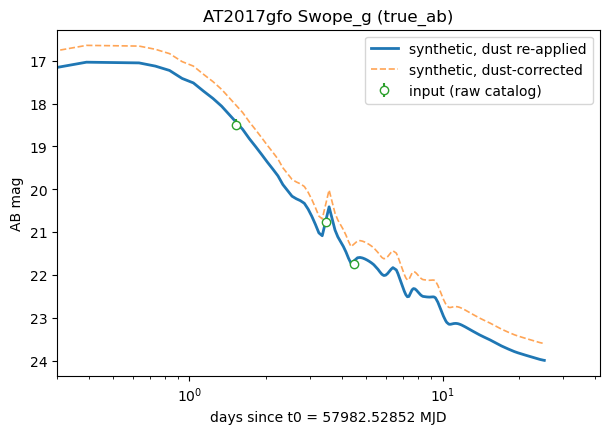

In [8]:
PLOT_BAND = "Swope_g"

g = grid[grid["band"] == PLOT_BAND]
o = raw[raw["band"] == PLOT_BAND]
fig, ax = plt.subplots(figsize=(7, 4.5))
if APPLY_EXTINCTION:
    ax.plot(g["phase_days"], g["mag_AB_obs"], "-", lw=2, label="synthetic, dust re-applied")
    ax.plot(g["phase_days"], g["mag_AB_dustcorr"], "--", lw=1.2, alpha=0.7, label="synthetic, dust-corrected")
else:
    ax.plot(g["phase_days"], g["mag_AB_model"], "-", lw=2, label="synthetic (as-is)")
ax.errorbar(o["MJD"] - T0_MJD, o["Mag"], yerr=o["Mag_err"], fmt="o", mfc="white", label="input (raw catalog)")
ax.set_xscale("log")
ax.set_xlim(0.3, None)
ax.invert_yaxis()
ax.set_xlabel("days since t0 = %.5f MJD" % T0_MJD)
ax.set_ylabel("AB mag")
ax.set_title("%s %s (%s)" % (SNNAME, PLOT_BAND, SYNTH_METHOD))
ax.legend()
plt.show()